# 🏭 Predictive Maintenance Analysis

## 📌 Project Overview

Machine failures can lead to unexpected downtime, increased maintenance costs, and reduced production efficiency. Instead of waiting for equipment to fail, predictive maintenance uses sensor data and machine learning to identify machines that are at risk of failure before breakdowns occur.

In this project, we analyze industrial machine data and build predictive models to classify whether a machine is likely to fail based on its operating conditions.

---

## 🎯 Business Problem

Unexpected equipment failures disrupt manufacturing processes and result in costly production delays. Traditional maintenance strategies are either reactive (after failure) or scheduled regardless of the machine's actual condition.

The goal of this project is to develop a predictive maintenance system that helps maintenance teams detect potential failures early, enabling proactive maintenance, reducing downtime, and improving operational efficiency.

# Imports

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import LabelEncoder
import os
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
import joblib

# ML imports
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay , classification_report ,roc_curve, auc
)
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
import joblib

RANDOM_STATE = 42
pd.set_option('display.max_columns', None)

# Consistent blue color palette used across all charts
BLUE_DARK = '#0B3D66'
BLUE_MAIN = '#1668A5'
BLUE_MED = '#3A8DCB'
BLUE_LIGHT = '#7FB8E0'
BLUE_PALE = '#CBE3F5'
BLUE_SEQUENCE = [BLUE_PALE, BLUE_LIGHT, BLUE_MED, BLUE_MAIN, BLUE_DARK]

pio.templates.default = 'plotly_white'

In [62]:
df = pd.read_csv("/kaggle/input/datasets/ayakhaled51/predictive-maintenance-cleaned-dataset-ai4i-2020/Predictive_Maintenance_Cleaned.csv")

df.head()

,Type,Air_Temperature,Process_Temperature,Rotational_Speed,Torque,Tool_Wear,Machine_Failure,Tool_Wear_Failure,Heat_Dissipation_Failure,Power_Failure,Overstrain_Failure,Random_Failure
0,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Type                      10000 non-null  object 
 1   Air_Temperature           10000 non-null  float64
 2   Process_Temperature       10000 non-null  float64
 3   Rotational_Speed          10000 non-null  int64  
 4   Torque                    10000 non-null  float64
 5   Tool_Wear                 10000 non-null  int64  
 6   Machine_Failure           10000 non-null  int64  
 7   Tool_Wear_Failure         10000 non-null  int64  
 8   Heat_Dissipation_Failure  10000 non-null  int64  
 9   Power_Failure             10000 non-null  int64  
 10  Overstrain_Failure        10000 non-null  int64  
 11  Random_Failure            10000 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 937.6+ KB


In [64]:
df.shape

(10000, 12)

In [65]:
df.describe()

,Air_Temperature,Process_Temperature,Rotational_Speed,Torque,Tool_Wear,Machine_Failure,Tool_Wear_Failure,Heat_Dissipation_Failure,Power_Failure,Overstrain_Failure,Random_Failure
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [66]:
df.isnull().sum()

Type                        0
Air_Temperature             0
Process_Temperature         0
Rotational_Speed            0
Torque                      0
Tool_Wear                   0
Machine_Failure             0
Tool_Wear_Failure           0
Heat_Dissipation_Failure    0
Power_Failure               0
Overstrain_Failure          0
Random_Failure              0
dtype: int64

In [67]:
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

Number of duplicate rows: 0


In [68]:
print(df['Machine_Failure'].value_counts())

Machine_Failure
0    9661
1     339
Name: count, dtype: int64


In [69]:
print(df['Type'].value_counts())

Type
L    6000
M    2997
H    1003
Name: count, dtype: int64


In [70]:
columns = [
    'Air_Temperature',
    'Process_Temperature',
    'Rotational_Speed',
    'Torque',
    'Tool_Wear'
]

for col in columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    count = ((df[col] < lower) | (df[col] > upper)).sum()

    print(f"{col}")
    print(f"Q1 = {Q1:.2f}")
    print(f"Q3 = {Q3:.2f}")
    print(f"Lower Bound = {lower:.2f}")
    print(f"Upper Bound = {upper:.2f}")
    print(f"Outliers = {count}")
    print("-" * 40)

Air_Temperature
Q1 = 298.30
Q3 = 301.50
Lower Bound = 293.50
Upper Bound = 306.30
Outliers = 0
----------------------------------------
Process_Temperature
Q1 = 308.80
Q3 = 311.10
Lower Bound = 305.35
Upper Bound = 314.55
Outliers = 0
----------------------------------------
Rotational_Speed
Q1 = 1423.00
Q3 = 1612.00
Lower Bound = 1139.50
Upper Bound = 1895.50
Outliers = 418
----------------------------------------
Torque
Q1 = 33.20
Q3 = 46.80
Lower Bound = 12.80
Upper Bound = 67.20
Outliers = 69
----------------------------------------
Tool_Wear
Q1 = 53.00
Q3 = 162.00
Lower Bound = -110.50
Upper Bound = 325.50
Outliers = 0
----------------------------------------


In [71]:
for col in columns:

    fig = px.box(
        df,
        x='Machine_Failure',
        y=col,
        color='Machine_Failure',
        title=f'<b>{col} vs Machine Failure</b>',
        color_discrete_map={
            0: BLUE_LIGHT,   # No Failure
            1: BLUE_DARK     # Failure
        }
    )

    fig.update_layout(
        title_x=0.5,
        title_font=dict(size=22, color='#044b94'),
        xaxis_title='Machine Failure',
        yaxis_title=col,
        legend_title='Status',
        font=dict(size=14),
        plot_bgcolor='white',
        paper_bgcolor='white'
    )

    fig.update_xaxes(
        tickvals=[0, 1],
        ticktext=['No Failure', 'Failure']
    )

    fig.show()

# Key Business Questions

### What is the total number of operations?

In [72]:
len(df)

10000

### What is the machine failure rate?

In [73]:
failure_rate = round(df['Machine_Failure'].mean() * 100, 2)
non_failure_rate = round(100 - failure_rate, 2)

print(f"Machine Failure Rate: {failure_rate}%")
print(f"Non-Failure Rate: {non_failure_rate}%")

Machine Failure Rate: 3.39%
Non-Failure Rate: 96.61%


In [74]:
df['Failure_Label'] = df['Machine_Failure'].map({0: 'No Failure', 1: 'Failure'})

failure_dist = df['Failure_Label'].value_counts().reindex(['No Failure', 'Failure'])
failure_dist_pct = (failure_dist / failure_dist.sum() * 100).round(1)

fig = go.Figure(go.Bar(
    x=failure_dist.index,
    y=failure_dist.values,
    marker_color=[BLUE_LIGHT, BLUE_DARK],
    text=[f'{p}%' for p in failure_dist_pct.values],
    textposition='outside'
))

fig.update_layout(
    title=dict(text='<b>Machine Failure Distribution</b>', x=0.5, font=dict(color='#044b94')),
    xaxis_title='',
    yaxis_title='Count',
    yaxis=dict(range=[0, failure_dist.values.max() * 1.2]),
    height=420,
    margin=dict(t=80)
)
fig.show()

### What is the distribution of product types?

In [75]:
type_counts = df['Type'].value_counts()

fig = go.Figure(go.Bar(
    x=type_counts.index,
    y=type_counts.values,
    marker_color=BLUE_SEQUENCE[1:4],
    text=type_counts.values,
    textposition='outside'
))

fig.update_layout(
    title=dict(text='<b>Product Type Distribution</b>', x=0.5, font=dict(color='#044b94')),
    xaxis_title='Product Type',
    yaxis_title='Count',
    yaxis=dict(range=[0, type_counts.values.max() * 1.2]),
    height=420,
    margin=dict(t=80)
)
fig.show()

### Which product type experiences the highest failure rate?

In [76]:
failure_rate_type = (
    (df.groupby('Type')['Machine_Failure'].mean() * 100)
    .round(2)
    .sort_values(ascending=False)
)

failure_rate_type

Type
L    3.92
M    2.77
H    2.09
Name: Machine_Failure, dtype: float64

In [77]:
fig = go.Figure(go.Bar(
    x=failure_rate_type.index,
    y=failure_rate_type.values,
    marker_color=[BLUE_DARK, BLUE_MED, BLUE_LIGHT],
    text=[f'{v:.2f}%' for v in failure_rate_type.values],
    textposition='outside'
))

fig.update_layout(
    title=dict(text='<b>Failure Rate by Product Type</b>', x=0.5, font=dict(color='#044b94')),
    xaxis_title='Product Type',
    yaxis_title='Failure Rate (%)',
    yaxis=dict(range=[0, failure_rate_type.values.max() * 1.2]),
    height=420,
    margin=dict(t=80)
)
fig.show()

### Does tool wear increase machine failure risk?

In [78]:
fig = px.violin(
    df,
    x='Failure_Label',
    y='Tool_Wear',
    color='Failure_Label',
    color_discrete_map={'No Failure': BLUE_LIGHT, 'Failure': BLUE_DARK},
    box=True
)

fig.update_layout(
    title=dict(text='<b>Tool Wear Distribution by Failure Status</b>', x=0.5, font=dict(color='#044b94')),
    xaxis_title='',
    yaxis_title='Tool Wear',
    showlegend=False,
    height=450
)
fig.show()

### How does failure rate change across tool wear ranges?

In [79]:
df['Wear_Group'] = pd.cut(
    df['Tool_Wear'],
    bins=[0, 50, 100, 150, 200, 250],
    labels=['0-50', '50-100', '100-150', '150-200', '200-250']
)

In [80]:
wear_failure = (
    df.groupby('Wear_Group', observed=False)['Machine_Failure']
      .mean()
      .mul(100)
      .round(2)
)

wear_failure

Wear_Group
0-50        2.15
50-100      2.33
100-150     2.18
150-200     2.90
200-250    15.26
Name: Machine_Failure, dtype: float64

In [81]:
fig = go.Figure(go.Scatter(
    x=wear_failure.index.astype(str),
    y=wear_failure.values,
    mode='lines+markers',
    line=dict(color=BLUE_MAIN, width=3),
    marker=dict(size=9, color=BLUE_DARK),
    fill='tozeroy',
    fillcolor='rgba(22, 104, 165, 0.12)'
))

fig.update_layout(
    title=dict(text='<b>Failure Rate by Tool Wear Group</b>', x=0.5, font=dict(color='#044b94')),
    xaxis_title='Tool Wear Group',
    yaxis_title='Failure Rate (%)',
    height=450
)
fig.show()

### What operating conditions are most common among failed machines?

In [82]:
df.groupby('Failure_Label')[[
    'Air_Temperature',
    'Process_Temperature',
    'Rotational_Speed',
    'Torque',
    'Tool_Wear'
]].mean().round(2)

,Air_Temperature,Process_Temperature,Rotational_Speed,Torque,Tool_Wear
Failure_Label,,,,,
Failure,300.89,310.29,1496.49,50.17,143.78
No Failure,299.97,310.00,1540.26,39.63,106.69


In [83]:
cols = [
    'Air_Temperature',
    'Process_Temperature',
    'Rotational_Speed',
    'Torque',
    'Tool_Wear'
]

comparison = (
    df.groupby('Failure_Label')[cols]
      .mean()
      .round(2)
      .T
)

comparison

Failure_Label,Failure,No Failure
Air_Temperature,300.89,299.97
Process_Temperature,310.29,310.00
Rotational_Speed,1496.49,1540.26
Torque,50.17,39.63
Tool_Wear,143.78,106.69


### Which failure type occurs most frequently?

In [84]:
failure_cols = [
    'Tool_Wear_Failure',
    'Heat_Dissipation_Failure',
    'Power_Failure',
    'Overstrain_Failure',
    'Random_Failure'
]

failure_counts = df[failure_cols].sum().sort_values(ascending=False)

failure_summary = pd.DataFrame({
    'Count': failure_counts,
    'Percentage (%)': (failure_counts / failure_counts.sum() * 100).round(2)
})

failure_summary

,Count,Percentage (%)
Heat_Dissipation_Failure,115,30.83
Overstrain_Failure,98,26.27
Power_Failure,95,25.47
Tool_Wear_Failure,46,12.33
Random_Failure,19,5.09


In [85]:
fig = go.Figure(go.Bar(
    x=failure_counts.index,
    y=failure_counts.values,
    marker_color=BLUE_SEQUENCE[::-1][:len(failure_counts)],
    text=failure_counts.values,
    textposition='outside'
))

fig.update_layout(
    title=dict(text='<b>Failure Types</b>', x=0.5, font=dict(color='#044b94')),
    xaxis_title='',
    yaxis_title='Count',
    yaxis=dict(range=[0, failure_counts.values.max() * 1.2]),
    xaxis_tickangle=-45,
    height=450,
    margin=dict(t=80)
)
fig.show()

### Does excessive mechanical stress increase failure risk?

In [86]:
df['Mechanical_Stress'] = df['Torque'] * df['Tool_Wear']

In [87]:
fig = px.violin(
    df,
    x='Failure_Label',
    y='Mechanical_Stress',
    color='Failure_Label',
    color_discrete_map={'No Failure': BLUE_LIGHT, 'Failure': BLUE_DARK},
    box=True
)

fig.update_layout(
    title=dict(text='<b>Mechanical Stress vs Failure</b>', x=0.5, font=dict(color='#044b94')),
    xaxis_title='',
    yaxis_title='Mechanical Stress',
    showlegend=False,
    height=450
)
fig.show()

### Can we identify an early warning indicator before failure occurs?

In [88]:
df.groupby('Failure_Label')[[
    'Tool_Wear',
    'Torque',
    'Process_Temperature',
    'Rotational_Speed'
]].mean().round(2)

,Tool_Wear,Torque,Process_Temperature,Rotational_Speed
Failure_Label,,,,
Failure,143.78,50.17,310.29,1496.49
No Failure,106.69,39.63,310.00,1540.26


### What are the most important factors driving machine failures?

In [89]:
df_corr = df.copy()

le = LabelEncoder()
df_corr['Type'] = le.fit_transform(df_corr['Type'])

In [90]:
corr = df_corr.drop(columns=['Wear_Group', 'Failure_Label']).corr().round(2)

fig = px.imshow(
    corr,
    text_auto=True,
    color_continuous_scale=['#FFFFFF', BLUE_LIGHT, BLUE_MAIN, BLUE_DARK],
    zmin=-1,
    zmax=1,
    aspect='auto'
)

fig.update_layout(
    title=dict(text='<b>Correlation Heatmap</b>', x=0.5, font=dict(color='#044b94')),
    height=600
)
fig.show()

# Machine Learning

In this section, we build and compare multiple machine learning models to predict **Machine_Failure**.

The dataset is split into training and testing sets (80/20), and **Stratified K-Fold Cross Validation** is used during hyperparameter tuning to reduce overfitting and ensure reliable performance on this relatively small dataset.

The selected models include **Logistic Regression, Random Forest, XGBoost, CatBoost, Support Vector Machine (SVM), and K-Nearest Neighbors (KNN)**. Each model is trained, evaluated, and compared using Accuracy, Precision, Recall, F1-score, ROC-AUC, and the Confusion Matrix to identify the best-performing model for predictive maintenance.

# Features and Target

In [91]:
# Columns that leak the target information (failure causes)
# These columns are removed before training to avoid data leakage.

leakage_columns = [
    'Tool_Wear_Failure',
    'Heat_Dissipation_Failure',
    'Power_Failure',
    'Overstrain_Failure',
    'Random_Failure'
]

df_model = df.drop(columns=leakage_columns)

print("Remaining Columns:")
print(df_model.columns.tolist())

Remaining Columns:
['Type', 'Air_Temperature', 'Process_Temperature', 'Rotational_Speed', 'Torque', 'Tool_Wear', 'Machine_Failure', 'Failure_Label', 'Wear_Group', 'Mechanical_Stress']


In [92]:
encoder = LabelEncoder()
df_model['Type'] = encoder.fit_transform(df_model['Type'])

df_model.head()

,Type,Air_Temperature,Process_Temperature,Rotational_Speed,Torque,Tool_Wear,Machine_Failure,Failure_Label,Wear_Group,Mechanical_Stress
0,2,298.1,308.6,1551,42.8,0,0,No Failure,NaN,0.0
1,1,298.2,308.7,1408,46.3,3,0,No Failure,0-50,138.9
2,1,298.1,308.5,1498,49.4,5,0,No Failure,0-50,247.0
3,1,298.2,308.6,1433,39.5,7,0,No Failure,0-50,276.5
4,1,298.2,308.7,1408,40.0,9,0,No Failure,0-50,360.0


In [93]:
df_model['Type'].value_counts()

Type
1    6000
2    2997
0    1003
Name: count, dtype: int64

In [94]:
# Features used for machine failure prediction
features = [
    'Type',
    'Air_Temperature',
    'Process_Temperature',
    'Rotational_Speed',
    'Torque',
    'Tool_Wear'
]

target = 'Machine_Failure'

X = df_model[features]
y = df_model[target]

print("Features shape:", X.shape)

print("\nTarget distribution:")
print(y.value_counts())

Features shape: (10000, 6)

Target distribution:
Machine_Failure
0    9661
1     339
Name: count, dtype: int64


# Train / Test Split (80% / 20%)

In [95]:
# Split the dataset into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Train size:", X_train.shape[0])
print("Test size :", X_test.shape[0])

# Verify that the class distribution is preserved
print("\nTrain Set Distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest Set Distribution:")
print(y_test.value_counts(normalize=True))

Train size: 8000
Test size : 2000

Train Set Distribution:
Machine_Failure
0    0.966125
1    0.033875
Name: proportion, dtype: float64

Test Set Distribution:
Machine_Failure
0    0.966
1    0.034
Name: proportion, dtype: float64


# Cross Validation Strategy

In [96]:
# Stratified K-Fold preserves the class distribution in every fold.
# It is used only during hyperparameter tuning on the training set.

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

# Evaluation Helper Function

In [97]:
# Dictionary to store the evaluation metrics of all models
results = {}

def evaluate_model(name, model, X_test, y_test):

    # Predictions
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    # Evaluation Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)

    print("=" * 50)
    print(name)
    print("=" * 50)

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-Score : {f1:.4f}")
    print(f"ROC-AUC  : {roc_auc:.4f}")

    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues')

    plt.title(f'Confusion Matrix - {name}', loc='center', fontweight='bold', color='#044b94')
    plt.show()

    # Store metrics
    results[name] = {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "ROC-AUC": roc_auc
    }

# Model 1 — Logistic Regression

Logistic Regression
Accuracy : 0.8210
Precision: 0.1411
Recall   : 0.8382
F1-Score : 0.2415
ROC-AUC  : 0.9062

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.82      0.90      1932
           1       0.14      0.84      0.24        68

    accuracy                           0.82      2000
   macro avg       0.57      0.83      0.57      2000
weighted avg       0.96      0.82      0.88      2000



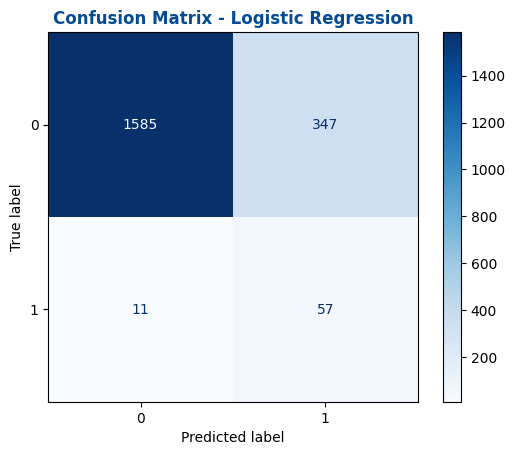

In [98]:
log_reg_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=RANDOM_STATE
    ))
])

# Train the model
log_reg_pipeline.fit(X_train, y_train)

# Evaluate the model
evaluate_model(
    "Logistic Regression",
    log_reg_pipeline,
    X_test,
    y_test
)


# Model 2 — Random Forest (Hyperparameter Tuning)

Best Random Forest Parameters:
{'max_depth': 15, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 300}
Random Forest
Accuracy : 0.9770
Precision: 0.6310
Recall   : 0.7794
F1-Score : 0.6974
ROC-AUC  : 0.9764

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.98      0.99      1932
           1       0.63      0.78      0.70        68

    accuracy                           0.98      2000
   macro avg       0.81      0.88      0.84      2000
weighted avg       0.98      0.98      0.98      2000



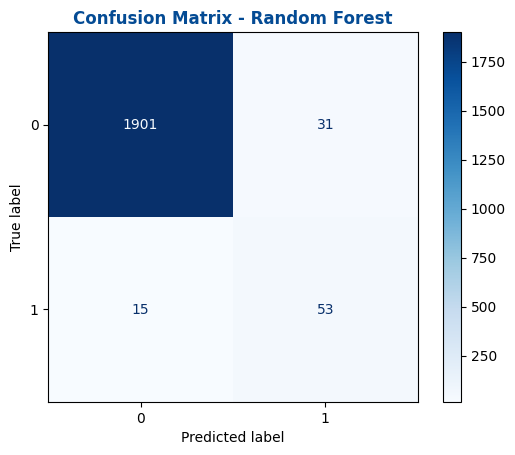

In [99]:
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_search = GridSearchCV(
    estimator=RandomForestClassifier(
        class_weight='balanced',
        random_state=RANDOM_STATE
    ),
    param_grid=rf_param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1
)

# Hyperparameter tuning + training
rf_search.fit(X_train, y_train)

print("Best Random Forest Parameters:")
print(rf_search.best_params_)

# Best trained model
random_forest_model = rf_search.best_estimator_

# Evaluate on the test set
evaluate_model(
    "Random Forest",
    random_forest_model,
    X_test,
    y_test
)

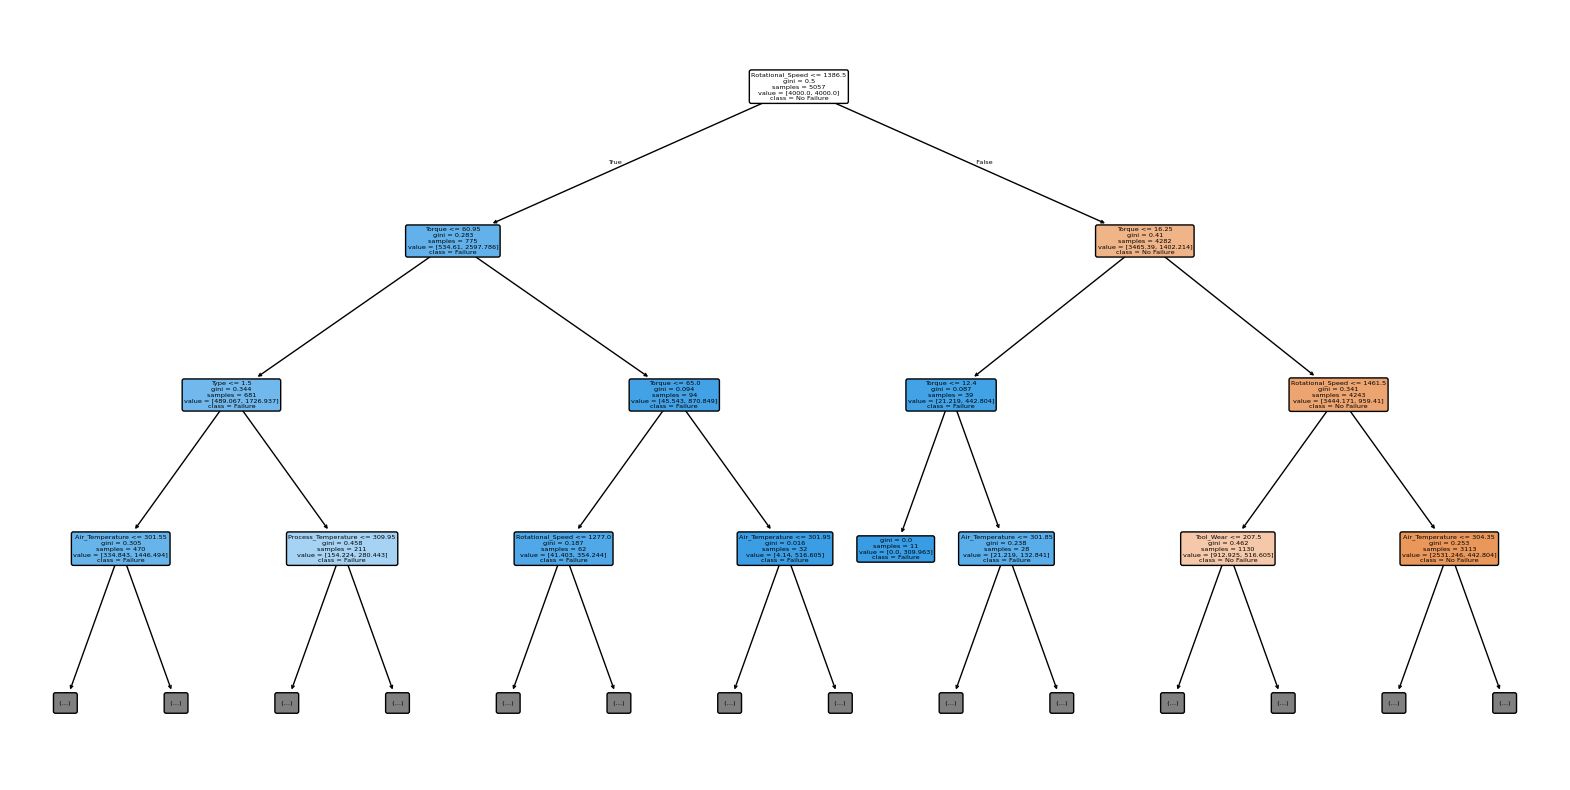

In [100]:
plt.figure(figsize=(20,10))

plot_tree(
    random_forest_model.estimators_[0],
    feature_names=X.columns,
    class_names=["No Failure", "Failure"],
    filled=True,
    rounded=True,
    max_depth=3
)

plt.show()

In [101]:
feature_importance = pd.DataFrame({

    "Feature": X.columns,
    "Importance": random_forest_model.feature_importances_

})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
4,Torque,0.334019
3,Rotational_Speed,0.288412
5,Tool_Wear,0.209881
1,Air_Temperature,0.097673
2,Process_Temperature,0.058742
0,Type,0.011273


In [102]:
fig = px.bar(
    feature_importance,
    x="Importance",
    y="Feature",
    orientation="h",
    color_discrete_sequence=[BLUE_MAIN],
)

fig.update_layout(
    title=dict(text="<b>Random Forest Feature Importance</b>", x=0.5, font=dict(color='#044b94')),
    template="plotly_white"
)

fig.update_yaxes(autorange="reversed")

fig.show()

# Model 3 — XGBoost (Hyperparameter Tuning)

In [103]:
# Handle class imbalance for XGBoost
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

print("scale_pos_weight =", scale_pos_weight)

scale_pos_weight = 28.52029520295203


Best XGBoost Parameters:
{'subsample': 0.8, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.05}
XGBoost
Accuracy : 0.9725
Precision: 0.5657
Recall   : 0.8235
F1-Score : 0.6707
ROC-AUC  : 0.9756

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.98      0.99      1932
           1       0.57      0.82      0.67        68

    accuracy                           0.97      2000
   macro avg       0.78      0.90      0.83      2000
weighted avg       0.98      0.97      0.97      2000



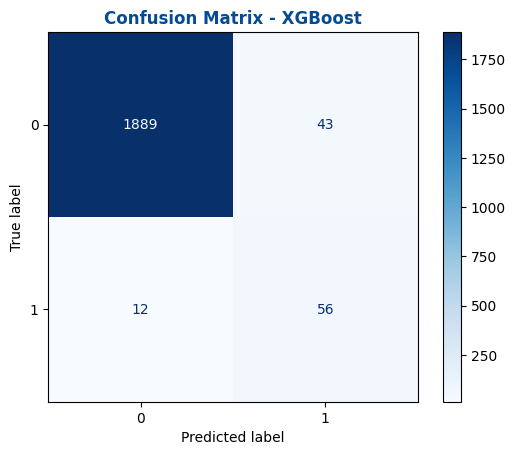

In [104]:
xgb_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0]
}

xgb_search = RandomizedSearchCV(
    estimator=XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        eval_metric='logloss',
        random_state=RANDOM_STATE
    ),
    param_distributions=xgb_param_grid,
    n_iter=15,
    cv=cv,
    scoring='roc_auc',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# Hyperparameter tuning + training
xgb_search.fit(X_train, y_train)

print("Best XGBoost Parameters:")
print(xgb_search.best_params_)

# Best trained model
xgboost_model = xgb_search.best_estimator_

# Evaluate
evaluate_model(
    "XGBoost",
    xgboost_model,
    X_test,
    y_test
)

In [105]:
xgb_importance = pd.DataFrame({

    "Feature": X.columns,
    "Importance": xgboost_model.feature_importances_

})

xgb_importance = xgb_importance.sort_values(
    by="Importance",
    ascending=False
)

xgb_importance

,Feature,Importance
3,Rotational_Speed,0.295714
4,Torque,0.295650
5,Tool_Wear,0.222698
1,Air_Temperature,0.089119
2,Process_Temperature,0.058336
0,Type,0.038483


In [106]:
fig = px.bar(
    xgb_importance,
    x="Importance",
    y="Feature",
    orientation="h",
    color_discrete_sequence=[BLUE_MAIN]
)

fig.update_layout(
    title=dict(text="<b>XGBoost Feature Importance</b>", x=0.5, font=dict(color='#044b94')),
    template="plotly_white"
)

fig.update_yaxes(autorange="reversed")


fig.show()

# Model 4 — CatBoost (Hyperparameter Tuning)

Best CatBoost Parameters:
{'learning_rate': 0.05, 'iterations': 200, 'depth': 4}
CatBoost
Accuracy : 0.9165
Precision: 0.2760
Recall   : 0.8971
F1-Score : 0.4221
ROC-AUC  : 0.9689

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.92      0.95      1932
           1       0.28      0.90      0.42        68

    accuracy                           0.92      2000
   macro avg       0.64      0.91      0.69      2000
weighted avg       0.97      0.92      0.94      2000



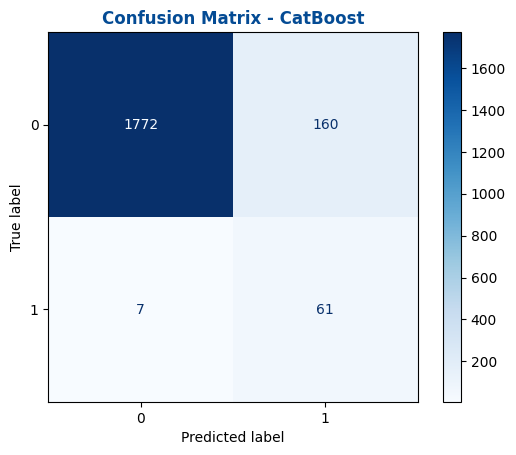

In [107]:
cat_param_grid = {
    'iterations': [200, 400],
    'depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1]
}

cat_search = RandomizedSearchCV(
    estimator=CatBoostClassifier(
        auto_class_weights='Balanced',
        verbose=0,
        random_state=RANDOM_STATE
    ),
    param_distributions=cat_param_grid,
    n_iter=10,
    cv=cv,
    scoring='roc_auc',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# Hyperparameter tuning + training
cat_search.fit(X_train, y_train)

print("Best CatBoost Parameters:")
print(cat_search.best_params_)

# Best trained model
catboost_model = cat_search.best_estimator_

# Evaluate
evaluate_model(
    "CatBoost",
    catboost_model,
    X_test,
    y_test
)

In [108]:
cat_importance = pd.DataFrame({

    "Feature": X.columns,
    "Importance": catboost_model.feature_importances_

})

cat_importance = cat_importance.sort_values(
    by="Importance",
    ascending=False
)

cat_importance

,Feature,Importance
4,Torque,34.161600
3,Rotational_Speed,22.833303
5,Tool_Wear,21.045292
1,Air_Temperature,13.225437
2,Process_Temperature,6.446692
0,Type,2.287677


In [109]:
fig = px.bar(
    cat_importance,
    x="Importance",
    y="Feature",
    orientation="h",
    color_discrete_sequence=[BLUE_MAIN]
)

fig.update_layout(
    title=dict(text="<b>CatBoost Feature Importance</b>", x=0.5, font=dict(color='#044b94')),
    template="plotly_white"
)

fig.update_yaxes(autorange="reversed")

fig.show()

# Model 5 — Support Vector Machine (Hyperparameter Tuning)

Best SVM Parameters:
{'model__C': 1, 'model__gamma': 'scale', 'model__kernel': 'rbf'}
SVM
Accuracy : 0.9185
Precision: 0.2831
Recall   : 0.9118
F1-Score : 0.4321
ROC-AUC  : 0.9644

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.92      0.96      1932
           1       0.28      0.91      0.43        68

    accuracy                           0.92      2000
   macro avg       0.64      0.92      0.69      2000
weighted avg       0.97      0.92      0.94      2000



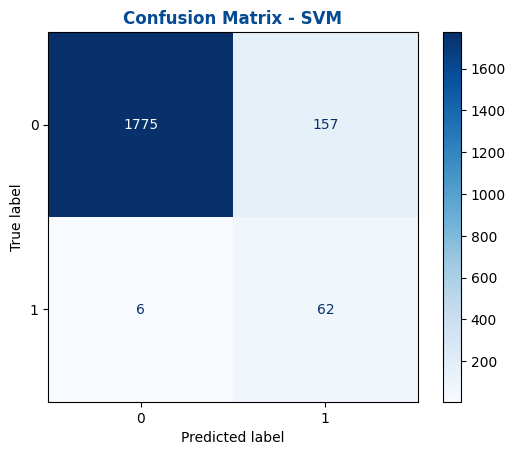

In [110]:
svm_param_grid = {
    'model__C': [0.1, 1, 10],
    'model__kernel': ['linear', 'rbf'],
    'model__gamma': ['scale', 'auto']
}

svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', SVC(
        class_weight='balanced',
        probability=True,
        random_state=RANDOM_STATE
    ))
])

svm_search = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=svm_param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1
)

# Hyperparameter tuning + training
svm_search.fit(X_train, y_train)

print("Best SVM Parameters:")
print(svm_search.best_params_)

# Best trained model
svm_model = svm_search.best_estimator_

# Evaluate
evaluate_model(
    "SVM",
    svm_model,
    X_test,
    y_test
)

# Model 6 — K-Nearest Neighbors (Hyperparameter Tuning)

Best KNN Parameters:
{'model__n_neighbors': 11, 'model__p': 1, 'model__weights': 'distance'}
KNN
Accuracy : 0.9715
Precision: 0.9231
Recall   : 0.1765
F1-Score : 0.2963
ROC-AUC  : 0.8662

Classification Report:

              precision    recall  f1-score   support

           0       0.97      1.00      0.99      1932
           1       0.92      0.18      0.30        68

    accuracy                           0.97      2000
   macro avg       0.95      0.59      0.64      2000
weighted avg       0.97      0.97      0.96      2000



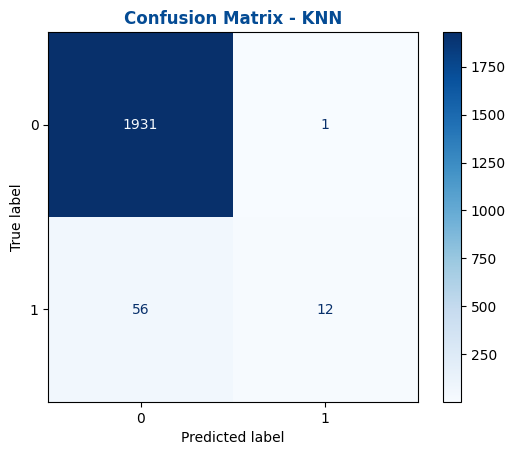

In [111]:
knn_param_grid = {
    'model__n_neighbors': [3, 5, 7, 9, 11],
    'model__weights': ['uniform', 'distance'],
    'model__p': [1, 2]
}

knn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', KNeighborsClassifier())
])

knn_search = GridSearchCV(
    estimator=knn_pipeline,
    param_grid=knn_param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1
)

# Hyperparameter tuning + training
knn_search.fit(X_train, y_train)

print("Best KNN Parameters:")
print(knn_search.best_params_)

# Best trained model
knn_model = knn_search.best_estimator_

# Evaluate
evaluate_model(
    "KNN",
    knn_model,
    X_test,
    y_test
)

# Model Comparison Table

In [112]:
comparison_df = pd.DataFrame(results).T
comparison_df = comparison_df.sort_values(by=['ROC-AUC', 'F1-Score'], ascending=False)
comparison_df


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Random Forest,0.9770,0.630952,0.779412,0.697368,0.976442
XGBoost,0.9725,0.565657,0.823529,0.670659,0.975559
CatBoost,0.9165,0.276018,0.897059,0.422145,0.968868
SVM,0.9185,0.283105,0.911765,0.432056,0.964369
Logistic Regression,0.8210,0.141089,0.838235,0.241525,0.906246
KNN,0.9715,0.923077,0.176471,0.296296,0.866151


# Ranking and Best Model Selection

In [113]:
models_dict = {
    "Logistic Regression": log_reg_pipeline,
    "KNN": knn_model,
    "SVM": svm_model,
    "Random Forest": random_forest_model,
    "XGBoost": xgb_search,
    "CatBoost": catboost_model
}

print("Model Ranking (Best → Worst)\n")
print(
    comparison_df[
        ["ROC-AUC", "F1-Score", "Accuracy", "Precision", "Recall"]
    ]
)

best_model_name = comparison_df.index[0]
best_model = models_dict[best_model_name]  

print(f"\nBest Model: {best_model_name}")

Model Ranking (Best → Worst)

                      ROC-AUC  F1-Score  Accuracy  Precision    Recall
Random Forest        0.976442  0.697368    0.9770   0.630952  0.779412
XGBoost              0.975559  0.670659    0.9725   0.565657  0.823529
CatBoost             0.968868  0.422145    0.9165   0.276018  0.897059
SVM                  0.964369  0.432056    0.9185   0.283105  0.911765
Logistic Regression  0.906246  0.241525    0.8210   0.141089  0.838235
KNN                  0.866151  0.296296    0.9715   0.923077  0.176471

Best Model: Random Forest


# ROC Curve

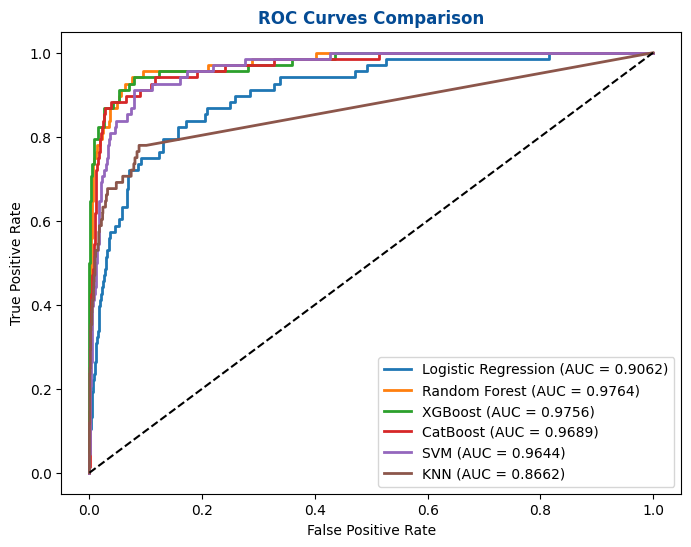

In [114]:
models_dict = {
    "Logistic Regression": log_reg_pipeline,
    "Random Forest": random_forest_model,
    "XGBoost": xgboost_model,
    "CatBoost": catboost_model,
    "SVM": svm_model,
    "KNN": knn_model,
}
plt.figure(figsize=(8,6))

for name, model in models_dict.items():

    y_proba = model.predict_proba(X_test)[:,1]

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC = {roc_auc:.4f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves Comparison", loc='center', fontweight='bold', color='#044b94')
plt.legend()

plt.show()

# Save Best Model

In [115]:
joblib.dump(best_model, "best_machine_failure_model.pkl")
joblib.dump(encoder, "label_encoder.pkl")


print("Best model saved successfully.")

Best model saved successfully.


# Load Model Again

In [116]:
loaded_model = joblib.load("best_machine_failure_model.pkl")

print(type(loaded_model))
print("Model loaded successfully.")

<class 'sklearn.ensemble._forest.RandomForestClassifier'>
Model loaded successfully.


In [117]:
new_sample = pd.DataFrame({

    "Type": [2],
    "Air_Temperature": [304.8],
    "Process_Temperature": [314.6],
    "Rotational_Speed": [1250],
    "Torque": [68],
    "Tool_Wear": [245]

})

prediction = loaded_model.predict(new_sample) 
probability = loaded_model.predict_proba(new_sample)
print("Prediction:", prediction[0]) 
print(f"Probability (Normal): {probability[0][0]:.4f}")
print(f"Probability (Failure): {probability[0][1]:.4f}")

Prediction: 1
Probability (Normal): 0.1463
Probability (Failure): 0.8537


In [118]:
new_sample = pd.DataFrame({
    "Type": [1],
    "Air_Temperature": [298.5],
    "Process_Temperature": [308.0],
    "Rotational_Speed": [1600],
    "Torque": [30],
    "Tool_Wear": [30]
})

prediction = loaded_model.predict(new_sample) 
probability = loaded_model.predict_proba(new_sample)
print("Prediction:", prediction[0]) 
print(f"Probability (Normal): {probability[0][0]:.4f}")
print(f"Probability (Failure): {probability[0][1]:.4f}")

Prediction: 0
Probability (Normal): 0.9971
Probability (Failure): 0.0029
